## Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import numpy as np

In [2]:
import os
import urllib.request

os.makedirs('data', exist_ok=True)

# Скачиваем файлы из репозитория, если их нет локально
files = {
    'data/orders.xlsx': 'https://raw.githubusercontent.com/EvgenySklyarov81/ad-hoc-sales-queries/main/data/orders.xlsx',
    'data/products.xlsx': 'https://raw.githubusercontent.com/EvgenySklyarov81/ad-hoc-sales-queries/main/data/products.xlsx',
}

for path, url in files.items():
    if not os.path.exists(path):
        print(f'Скачиваю {path}...')
        urllib.request.urlretrieve(url, path)
    else:
        print(f'{path} уже существует')

print('Данные готовы.')

data/orders.xlsx уже существует
data/products.xlsx уже существует
Данные готовы.


In [3]:
orders = pd.read_excel('data/orders.xlsx')
products = pd.read_excel('data/products.xlsx')
products.columns = ['product_id', 'category', 'sub_category', 'name']

## Знакомство с данными

### Датасет 1, заказы

In [4]:
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3323 entries, 0 to 3322
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       3323 non-null   int64         
 1   accepted_at    3323 non-null   datetime64[ns]
 2   product_id     3323 non-null   int64         
 3   quantity       3323 non-null   int64         
 4   regular_price  3323 non-null   int64         
 5   price          3323 non-null   int64         
 6   cost_price     3323 non-null   int64         
dtypes: datetime64[ns](1), int64(6)
memory usage: 181.9 KB


,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130


### Датасет 2, товары

In [5]:
products.info()
products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40152 entries, 0 to 40151
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    40152 non-null  int64 
 1   category      40152 non-null  object
 2   sub_category  40152 non-null  object
 3   name          39940 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB


,product_id,category,sub_category,name
0,1,Гигиена,Бритье,Кассеты для бритья Gillette Fusion ProGlide Po...
1,2,Мучные кондитерские изделия,Мучные кондитерские изделия,Печенье Бодрость
2,3,Мясная гастрономия,"Сосиски, сардельки",Сосиски Стародворье
3,4,Чай,Черный чай,Чай Азерчай
4,5,Безалкогольные напитки,Соковая продукция,Морс Valio


# Самая ходовая товарная группа  
### По какой категории товаров продано больше всего позиций?

In [6]:
# при соединении отбрасываем товары, отсутствующие в справочнике товаров т.к. нам необходимы названия категорий для каждого товара в продажах
df = orders.merge(products)

In [7]:
df.sample(3)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,category,sub_category,name
1585,1517544601,2022-01-13 14:23:42,1362,4,59,59,34,Детское питание,Не молочное детское питание,Пюре ФрутоНяня
987,1517598991,2022-01-13 11:14:21,20753,1,109,93,60,Консервированные продукты,Консервы рыбные,Сардина Вкусные Консервы
1302,1517346608,2022-01-13 11:37:20,10141,2,1797,1797,808,"Кофе, какао",Кофе,Кофе в зернах Egoiste


In [8]:
qty_by_category = df.groupby(['category'])['quantity'].agg('sum').reset_index().sort_values('quantity')
qty_by_category

,category,quantity
22,Специальное питание,2
5,Детство (Гигиена и Уход),6
17,Рыба,8
9,"Кофе, какао",21
2,Бытовая химия,23
24,Уход,24
14,Мясо,29
26,Чай,40
27,Яичные товары,40
18,Рыбная гастрономия,44


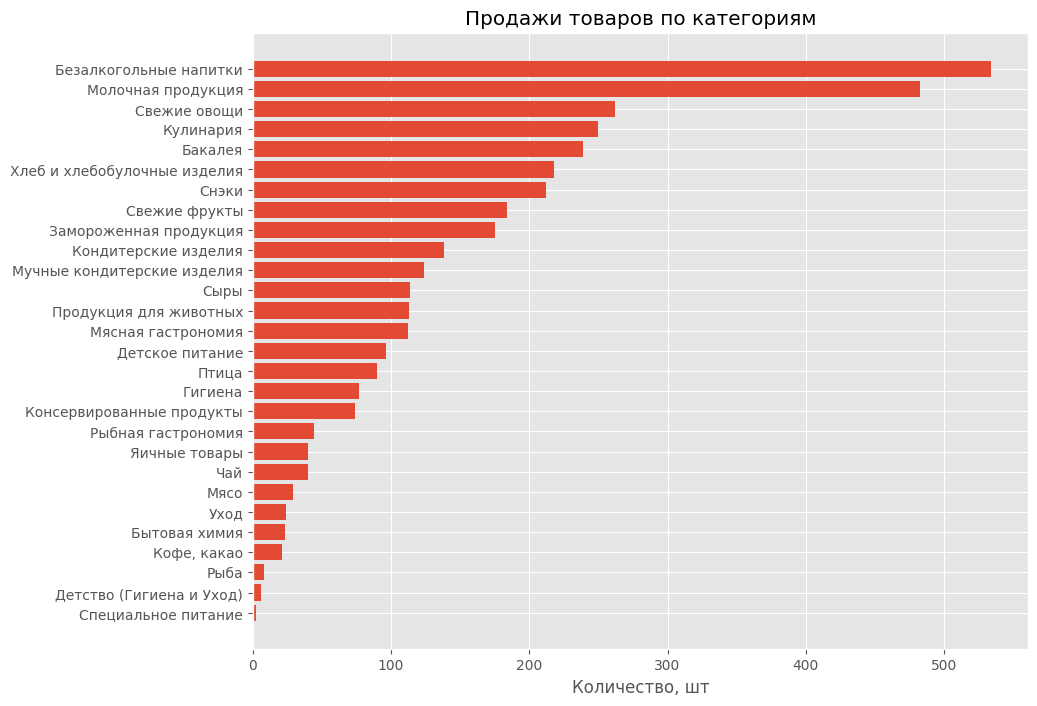

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh('category', 'quantity', data=qty_by_category)
ax.set_xlabel('Количество, шт')
ax.set_title('Продажи товаров по категориям');

# Распределение продаж по подкатегориям
### Оценить распределение количества проданных позиций в каждой товарной категории по подкатегориям

In [10]:
cat_sub_cat = df.groupby(['category', 'sub_category'])['quantity'].agg('sum').reset_index().sort_values(['category', 'quantity', 'sub_category'], ascending=[True, False, True])
cat_sub_cat

,category,sub_category,quantity
10,Бакалея,Сухие блюда быстрого приготовления,38
3,Бакалея,"Крупы, бобовые",30
1,Бакалея,Зерновые для завтраков,24
4,Бакалея,Макаронные изделия,24
9,Бакалея,Соусы,24
...,...,...,...
95,Хлеб и хлебобулочные изделия,Хлеб и хлебобулочные изделия,218
98,Чай,Черный чай,26
96,Чай,Зеленый чай,7
97,Чай,Чайные напитки,7


# Найти средний чек в заданную дату
### Какой средний чек был 13.01.2022?

In [11]:
orders['total'] = orders['quantity'] * orders['price']

In [12]:
# располагаем данными о продажах только за один день
orders['accepted_at'].min(), orders['accepted_at'].max()

(Timestamp('2022-01-13 08:00:30'), Timestamp('2022-01-13 22:58:29'))

In [13]:
avg_bill = round(orders.groupby('order_id')['total'].agg('sum').mean(), 2)
print(f'Средний чек за 13.01.2022: {avg_bill}')

Средний чек за 13.01.2022: 915.64


# Доля промо в заданной категории
### Какую долю от общих продаж категории Сыры занимают промо (в штуках)

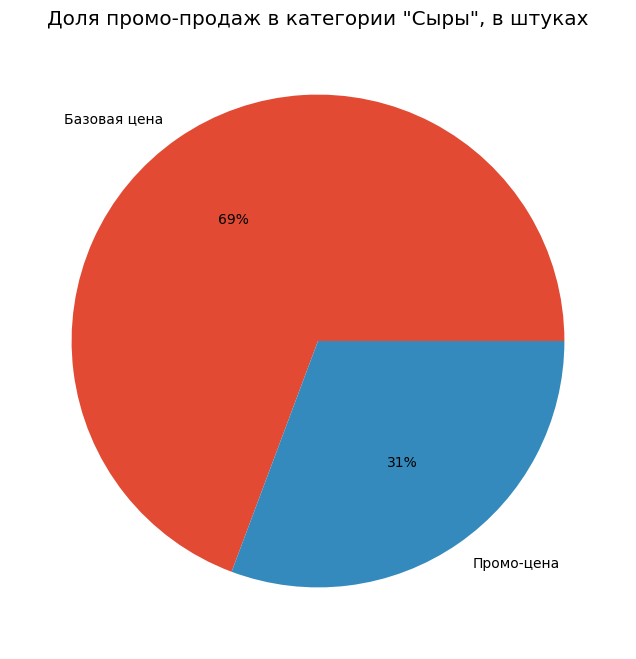

In [14]:
cheese = df[df['category'] == 'Сыры']

# все продажи сыров и промо-продажи сыров в штуках
regular = cheese[cheese['price'] == cheese['regular_price']]['quantity'].sum()
promo = cheese[cheese['price'] != cheese['regular_price']]['quantity'].sum()

data = [regular, promo]
labels = ['Базовая цена', 'Промо-цена']

fig, ax = plt.subplots(figsize=(10, 8))
ax.pie(data, labels=labels, autopct='%1.0f%%')
ax.set_title('Доля промо-продаж в категории "Сыры", в штуках');

# Посчитать маржу по категориям
* В рублях
* В %

In [15]:
cat_margin = df.copy()
cat_margin['revenue'] = cat_margin['quantity'] * cat_margin['price']
cat_margin['margin'] = cat_margin['quantity'] * (cat_margin['price'] - cat_margin['cost_price'])

In [16]:
cat_margin = cat_margin.groupby('category')[['revenue', 'margin']].agg('sum')

In [17]:
cat_margin['marginality'] = round(cat_margin['margin'] / cat_margin['revenue'] * 100, 2)

In [18]:
cat_margin = cat_margin.drop(columns='revenue')

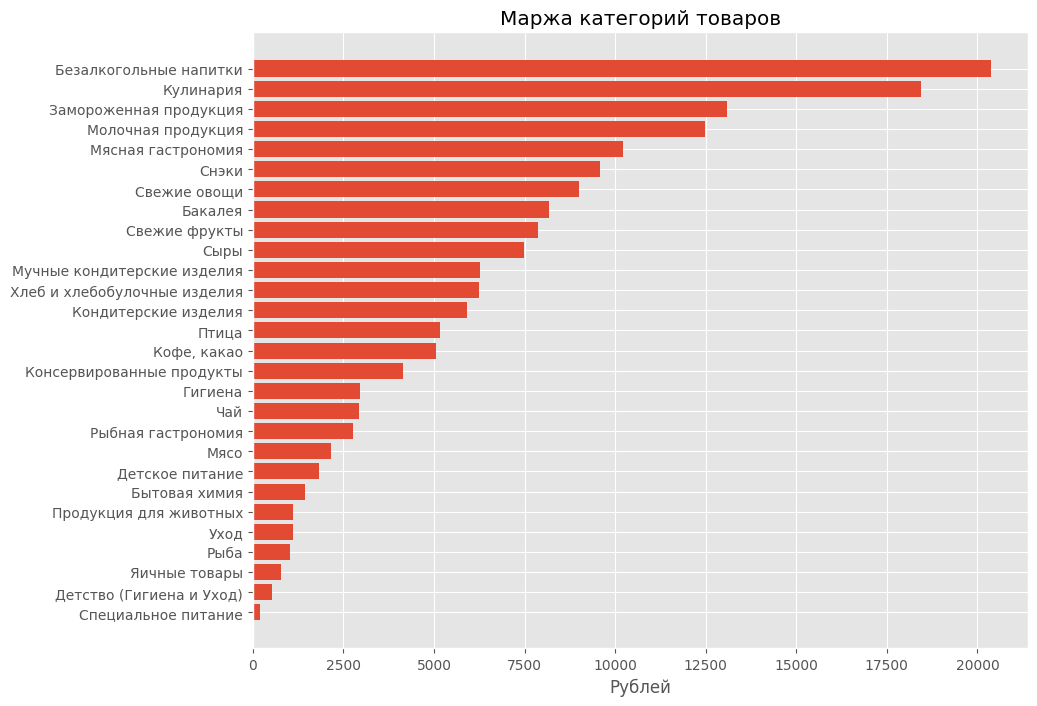

In [19]:
category = cat_margin.sort_values('margin').index
margin = cat_margin['margin'].sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(category, margin)
ax.set_title('Маржа категорий товаров')
ax.set_xlabel('Рублей');

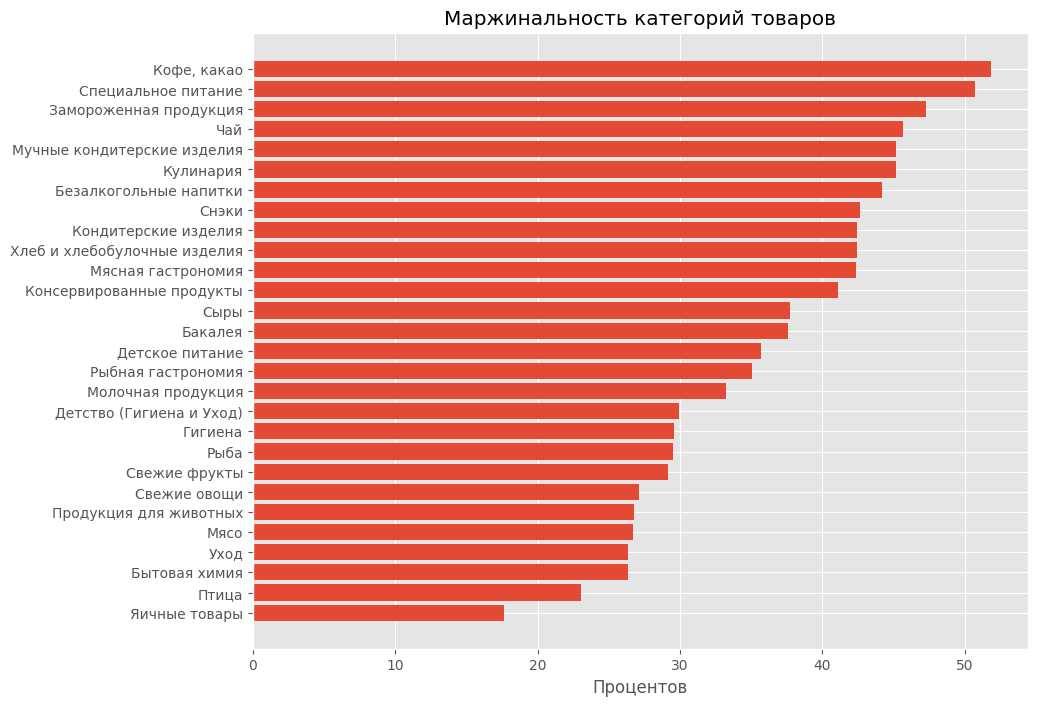

In [20]:
category = cat_margin.sort_values('marginality').index
marginality = cat_margin['marginality'].sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(category, marginality)
ax.set_title('Маржинальность категорий товаров')
ax.set_xlabel('Процентов');

# ABC анализ по подкатегориям
* ABC-анализ продаж по количеству
* ABC-анализ по сумме продаж

In [21]:
dataset = df.assign(revenue=df['quantity'] * df['price'])

In [22]:
dataset = dataset.groupby('sub_category')[['quantity', 'revenue']].agg('sum')

In [23]:
total_qty = dataset['quantity'].sum()
abc_qty = dataset['quantity'].sort_values(ascending=False).reset_index()
abc_qty['cum_qty'] = abc_qty['quantity'].cumsum()
abc_qty['ratio'] = abc_qty['cum_qty'] / total_qty
abc_qty['qty_group'] = np.where(abc_qty['ratio'] <= 0.8, 'A', np.where(abc_qty['ratio'] <= 0.95, 'B', 'C'))
abc_qty = abc_qty[['sub_category', 'qty_group']]

In [24]:
total_rev = dataset['revenue'].sum()
abc_rev = dataset['revenue'].sort_values(ascending=False).reset_index()
abc_rev['cum_revenue'] = abc_rev['revenue'].cumsum()
abc_rev['ratio'] = abc_rev['cum_revenue'] / total_rev
abc_rev['rev_group'] = np.where(abc_rev['ratio'] <= 0.8, 'A', np.where(abc_rev['ratio'] <= 0.95, 'B', 'C'))
abc_rev = abc_rev[['sub_category', 'rev_group']]

In [25]:
abc_result = abc_qty.merge(abc_rev)
abc_result = (
    abc_result.assign(group=abc_result['qty_group'] + abc_result['rev_group'])
    .drop(columns=['qty_group', 'rev_group'])
    .sort_values(['group', 'sub_category'])
    .reset_index(drop=True)
)
abc_result

,sub_category,group
0,"Бананы, косточковые и прочие плоды",AA
1,Бумажная продукция,AA
2,Воды питьевые,AA
3,Готовые блюда,AA
4,Замороженные полуфабрикаты,AA
...,...,...
95,Субпродуктовые изделия,CC
96,Уход за детьми,CC
97,Уход за кожей лица,CC
98,Уход за одеждой и обувью,CC
